# Tutorial 4: $T_c$ Parameter Sweeps and Phase Diagrams

This tutorial demonstrates the `tc_parameter_sweep()` and `tc_phase_diagram()`
functions introduced in `supermag.sweeps`. These utilities make it easy to
explore how the critical temperature of an S/F bilayer depends on any
combination of physical parameters.

In [1]:
import sys
sys.path.insert(0, r"c:\Users\seans\Documents\GitHub\SUPERMag-Simulation-Suite\python")

import numpy as np
import matplotlib.pyplot as plt
import supermag

print(f"SUPERMag functions available: {[x for x in dir(supermag) if not x.startswith('_')]}")

SUPERMag functions available: ['apply_theme', 'bdg', 'critical_temperature', 'eilenberger', 'get_material', 'get_theme', 'ginzburg_landau', 'josephson', 'list_materials', 'list_themes', 'materials', 'pair_amplitude', 'proximity', 'sweeps', 'tc_parameter_sweep', 'tc_phase_diagram', 'theme_context', 'themes', 'triplet', 'usadel']


## 1. Basic $T_c(d_F)$ Sweep

The most common experiment: vary the ferromagnet thickness $d_F$ and measure
how $T_c$ oscillates and decays. `tc_parameter_sweep()` with `sweep_var='d_F'`
handles this directly.

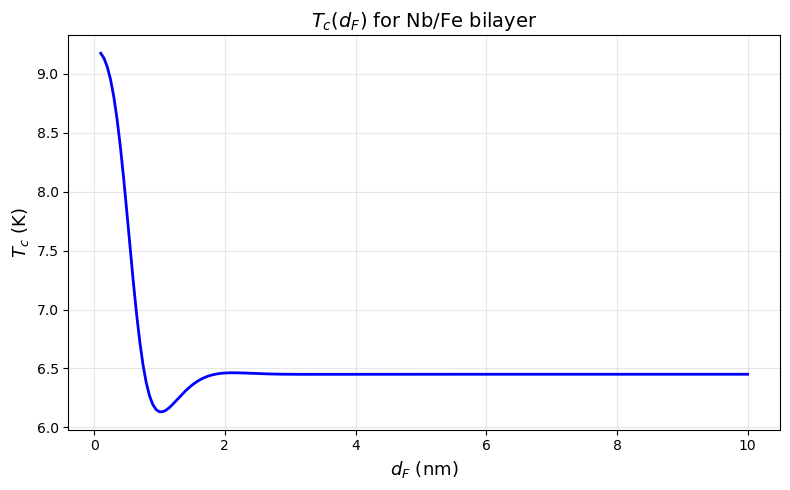

Result keys: ['sweep_var', 'sweep_values', 'd_F', 'Tc']
Tc range: 6.13 – 9.17 K


In [2]:
nb = supermag.get_material('Nb')
fe = supermag.get_material('Fe')

d_F = np.linspace(0.1, 10, 200)

result = supermag.tc_parameter_sweep(
    sweep_var='d_F',
    sweep_values=d_F,
    Tc0=nb['Tc'], d_S=50.0,
    E_ex=fe['E_ex'], xi_S=nb['xi_S'], xi_F=fe['xi_F']
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(result['d_F'], result['Tc'], 'b-', lw=2)
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title(r'$T_c(d_F)$ for Nb/Fe bilayer', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Result keys: {list(result.keys())}")
print(f"Tc range: {result['Tc'].min():.2f} – {result['Tc'].max():.2f} K")

## 2. Sweeping Other Parameters

Any of `'d_F'`, `'d_S'`, `'gamma'`, `'gamma_B'`, `'E_ex'`, `'xi_F'`, or `'Tc0'`
can be swept. When sweeping a parameter other than `d_F`, you must supply a
`d_F_array`.

Let's sweep `gamma` (the S/F interface transparency), which controls
pair-breaking. In S/F bilayers the complex pair-breaking kernel causes a
**first-order** transition to the normal state at a critical $\gamma_c$,
unlike the second-order Abrikosov–Gor'kov transition with real pair-breaking.
The critical $\gamma_c$ depends on the ferromagnet thickness.

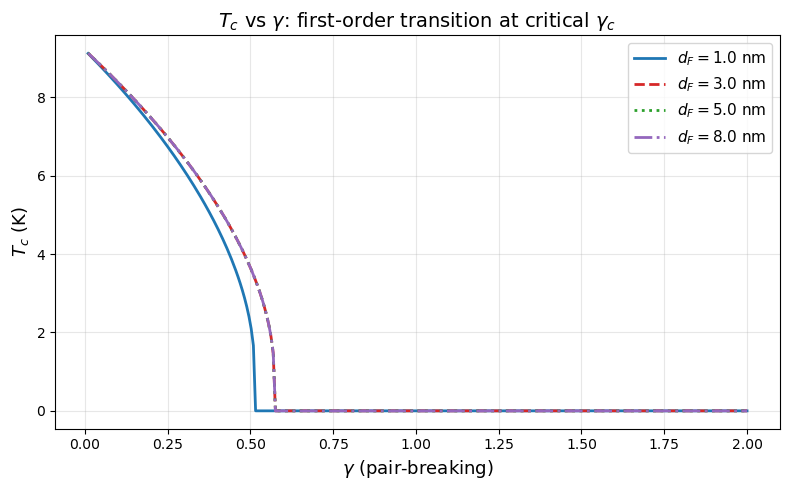

In [3]:
gamma_vals = np.linspace(0.01, 2.0, 300)

fig, ax = plt.subplots(figsize=(8, 5))

for d_F_val, color, ls in [(1.0, '#1f77b4', '-'),
                            (3.0, '#d62728', '--'),
                            (5.0, '#2ca02c', ':'),
                            (8.0, '#9467bd', '-.')]:
    result = supermag.tc_parameter_sweep(
        sweep_var='gamma',
        sweep_values=gamma_vals,
        d_F_array=np.array([d_F_val]),
        Tc0=nb['Tc'], d_S=50.0,
        E_ex=fe['E_ex'], xi_S=nb['xi_S'], xi_F=fe['xi_F']
    )
    Tc = result['Tc'].flatten()
    ax.plot(gamma_vals, Tc, color=color, ls=ls, lw=2,
            label=rf'$d_F = {d_F_val}$ nm')

ax.set_xlabel(r'$\gamma$ (pair-breaking)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title(r'$T_c$ vs $\gamma$: first-order transition at critical $\gamma_c$',
             fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Exchange Energy Sweep (auto $\xi_F$)

When sweeping `E_ex`, the function **automatically recomputes** $\xi_F$ from
$\xi_F = \sqrt{\hbar D_F / E_{ex}}$ at each point. This is physical: a larger
exchange energy shortens the ferromagnetic coherence length.

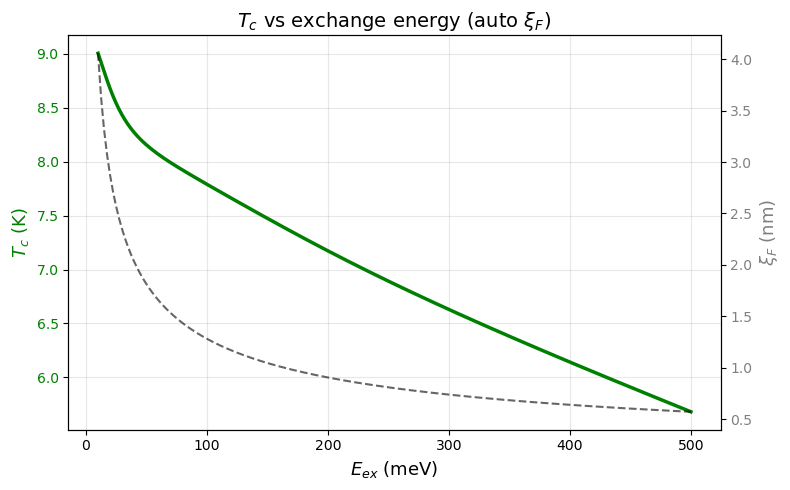

In [4]:
E_ex_vals = np.linspace(10, 500, 200)  # meV

# Do NOT pass xi_F — the sweep auto-recomputes xi_F(E_ex) = sqrt(hbar*D_F/E_ex)
result_eex = supermag.tc_parameter_sweep(
    sweep_var='E_ex',
    sweep_values=E_ex_vals,
    d_F_array=np.array([3.0]),
    Tc0=nb['Tc'], d_S=50.0, xi_S=nb['xi_S'],  # no xi_F!
    D_F=fe['D_F'],
)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(E_ex_vals, result_eex['Tc'].flatten(), 'g-', lw=2.5)
ax1.set_xlabel(r'$E_{ex}$ (meV)', fontsize=13)
ax1.set_ylabel(r'$T_c$ (K)', fontsize=13, color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, alpha=0.3)

# Secondary axis: show the implied xi_F
import scipy.constants as const
xi_F_auto = np.sqrt(const.hbar * fe['D_F'] / (E_ex_vals * const.eV * 1e-3)) * 1e9
ax2 = ax1.twinx()
ax2.plot(E_ex_vals, xi_F_auto, 'k--', lw=1.5, alpha=0.6)
ax2.set_ylabel(r'$\xi_F$ (nm)', fontsize=13, color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

ax1.set_title(r'$T_c$ vs exchange energy (auto $\xi_F$)', fontsize=14)
fig.tight_layout(); plt.show()

## 4. Comparing Multiple Ferromagnets

Use the material database and sweeps together to compare different
S/F combinations.

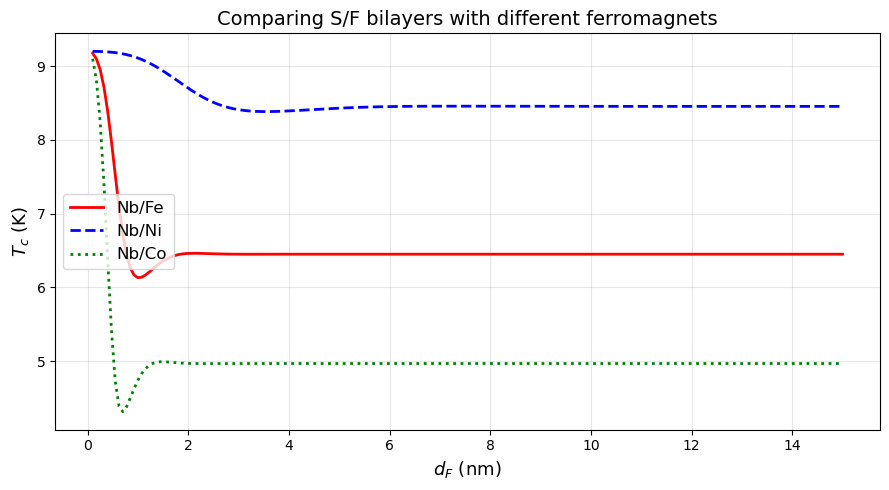

In [5]:
d_F = np.linspace(0.1, 15, 200)
nb = supermag.get_material('Nb')

fig, ax = plt.subplots(figsize=(9, 5))

for fm_name, color, ls in [('Fe', 'red', '-'), ('Ni', 'blue', '--'), ('Co', 'green', ':')]:
    fm = supermag.get_material(fm_name)
    result = supermag.tc_parameter_sweep(
        sweep_var='d_F',
        sweep_values=d_F,
        Tc0=nb['Tc'], d_S=50.0,
        E_ex=fm['E_ex'], xi_S=nb['xi_S'], xi_F=fm['xi_F']
    )
    ax.plot(d_F, result['Tc'], color=color, ls=ls, lw=2, label=f'Nb/{fm_name}')

ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title('Comparing S/F bilayers with different ferromagnets', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5. 2D Phase Diagram

`tc_phase_diagram()` builds a 2D grid over any two parameters. This is ideal
for mapping out the $T_c(d_F, \xi_F)$ or $T_c(d_F, \gamma_B)$ landscape.

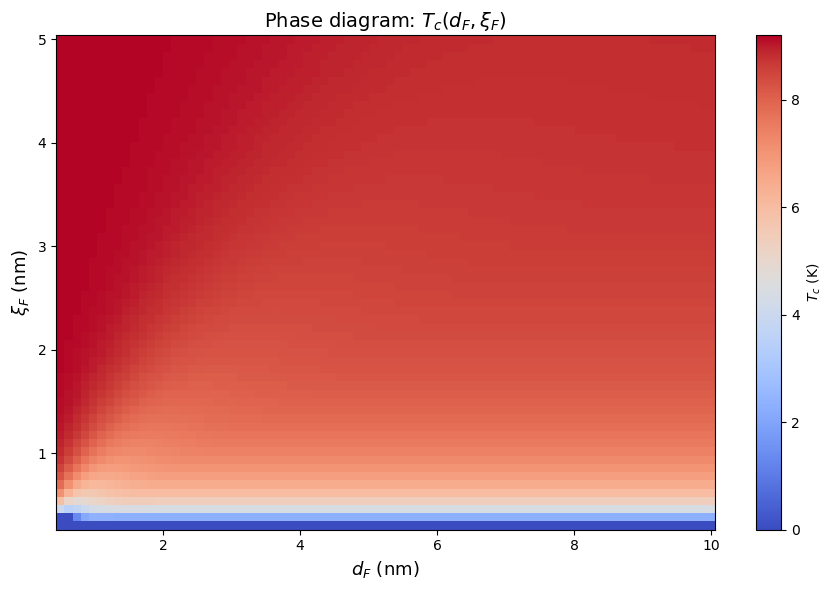

Phase diagram shape: (80, 60)
Tc range: 0.00 – 9.20 K


In [6]:
d_F_vals = np.linspace(0.5, 10, 80)
xi_F_vals = np.linspace(0.3, 5.0, 60)

phase = supermag.tc_phase_diagram(
    var1='d_F', vals1=d_F_vals,
    var2='xi_F', vals2=xi_F_vals,
    Tc0=nb['Tc'], d_S=50.0, E_ex=fe['E_ex'], xi_S=nb['xi_S']
)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.pcolormesh(d_F_vals, xi_F_vals, phase['Tc'].T,
                    cmap='coolwarm', shading='auto')
plt.colorbar(im, ax=ax, label=r'$T_c$ (K)')
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$\xi_F$ (nm)', fontsize=13)
ax.set_title(r'Phase diagram: $T_c(d_F, \xi_F)$', fontsize=14)
plt.tight_layout(); plt.show()

print(f"Phase diagram shape: {phase['Tc'].shape}")
print(f"Tc range: {phase['Tc'].min():.2f} – {phase['Tc'].max():.2f} K")

## 6. $d_F$–$\gamma_B$ Phase Diagram

Another experimentally relevant slice: how interface transparency $\gamma_B$
affects the oscillation pattern.

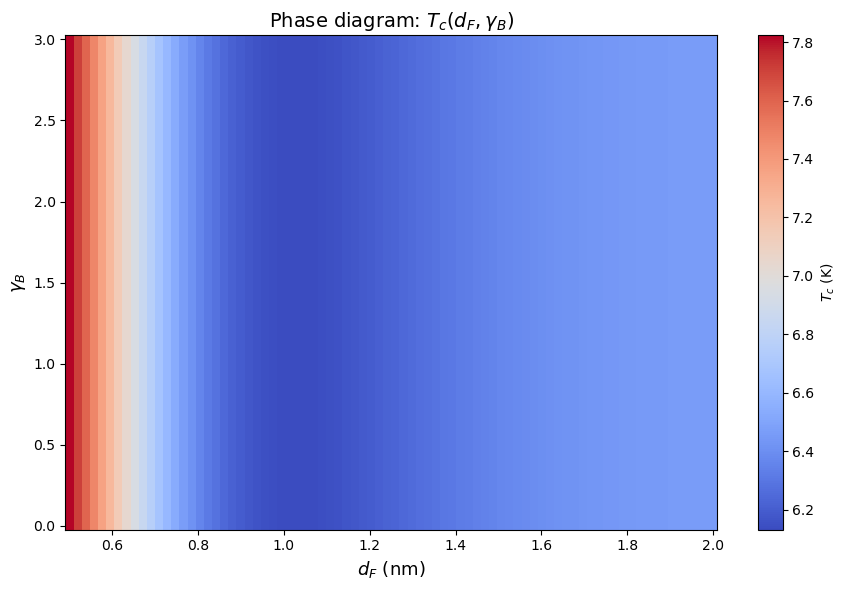

In [8]:
d_F_vals = np.linspace(0.5, 2, 80)
gamma_B_vals = np.linspace(0.0, 3.0, 60)

phase_gB = supermag.tc_phase_diagram(
    var1='d_F', vals1=d_F_vals,
    var2='gamma_B', vals2=gamma_B_vals,
    Tc0=nb['Tc'], d_S=50.0, E_ex=fe['E_ex'], xi_S=nb['xi_S'], xi_F=fe['xi_F']
)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.pcolormesh(d_F_vals, gamma_B_vals, phase_gB['Tc'].T,
                    cmap='coolwarm', shading='auto')
plt.colorbar(im, ax=ax, label=r'$T_c$ (K)')
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$\gamma_B$', fontsize=13)
ax.set_title(r'Phase diagram: $T_c(d_F, \gamma_B)$', fontsize=14)
plt.tight_layout(); plt.show()

## Summary

| Function | Purpose | Key parameter |
|:---------|:--------|:--------------|
| `tc_parameter_sweep()` | 1D sweep over any parameter | `sweep_var` |
| `tc_phase_diagram()` | 2D grid over two parameters | `var1`, `var2` |

Both functions wrap `critical_temperature()` and handle parameter dispatch,
automatic $\xi_F$ recomputation (for `E_ex` sweeps), and array broadcasting
internally.

**Next steps:**
- Overlay experimental data with `ax.errorbar()`
- Fit model parameters to data using `scipy.optimize`
- Explore triplet effects with the upcoming triplet pipeline